# EDA, Análisis exploratorio gastos personales


EDA de más de N movimientos bancarios: categorización automática de gastos, análisis mensual por categoría e identificación de patrones de consumo.

## Pregunta de negocio:

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

### Subpreguntas

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?
2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?
3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

### Parte predictiva

1. Dado mi historial de ingresos y gastos por categoría, ¿cuál es mi gasto y ahorro esperados el próximo mes si no cambio nada?
2. ¿Qué efecto tendría reducir un X % el gasto en determinadas categorías sobre mi ahorro esperado?

### Importaciones de librerias

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import calendar  # usado para obtener nombres de meses ordenados de forma fiable
from pathlib import Path
import streamlit as st
from datetime import datetime


### Configuración personalizada
Para darle entidad al proyecto

In [2]:
empresa_colors = ["#003f5c", "#1e829b", "#7b26bc"]

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=empresa_colors)
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.titleweight'] = "bold"




### Carga de datos e Información del dataset

In [3]:
#Forma mas robusta de poder obtener la ruta de los datos, asi puede abrir el archivo en diferentes ordenadores. 

import os

try:
    # Obtener ruta del proyecto (raíz) de forma robusta
    # Esta ruta funciona sin importar desde dónde se ejecute el notebook
    project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
    datos = project_root / "data" / "raw" / "gastos_personales_2024.csv"

    print(f"📂 Ruta del proyecto: {project_root}")
    print(f"📄 Buscando CSV en: {datos}")
    
    # Validar que el archivo existe
    if not datos.exists():
        raise FileNotFoundError(f"❌ No se encontró el CSV en: {datos}")
    print(f"✅ CSV encontrado")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    raise
except Exception as e:
    print(f"Error inesperado al buscar el archivo: {e}")
    raise


📂 Ruta del proyecto: c:\Users\maxim\Proyectos\analisis_gastos_personales
📄 Buscando CSV en: c:\Users\maxim\Proyectos\analisis_gastos_personales\data\raw\gastos_personales_2024.csv
✅ CSV encontrado


### Crear dir para las imagenes a descargar

In [4]:
#creo la carpeta si no existe
outdir = Path("../reports/figures")
outdir.mkdir(parents=True, exist_ok=True)

In [5]:
from src.iniciar_dataframe import informacion_df

# Función propia para analizar el dataframe. De forma rápida y sencilla, arroja todos los datos necesarios
df = informacion_df(str(datos))


▶ Head (5 filas):


,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta



▶ Info del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  582 non-null    object 
 1   tipo_movimiento        582 non-null    object 
 2   categoria              582 non-null    object 
 3   importe_eur            582 non-null    float64
 4   saldo_post_movimiento  582 non-null    float64
 5   descripcion            582 non-null    object 
 6   canal                  582 non-null    object 
dtypes: float64(2), object(5)
memory usage: 32.0+ KB

▶ Dimensiones (shape):
(582, 7)

▶ Columnas:
['fecha', 'tipo_movimiento', 'categoria', 'importe_eur', 'saldo_post_movimiento', 'descripcion', 'canal']

▶ Descripción estadística (describe numérico):


,importe_eur,saldo_post_movimiento
count,582.000000,582.000000
mean,-7.873660,-267.471684
std,366.015027,1767.677453
min,-1033.920000,-3159.600000
25%,-50.307500,-1951.422500
50%,-35.770000,-317.070000
75%,-21.582500,1127.265000
max,2442.580000,4874.510000



▶ Tipos de datos:
fecha                     object
tipo_movimiento           object
categoria                 object
importe_eur              float64
saldo_post_movimiento    float64
descripcion               object
canal                     object
dtype: object


### Limpieza de datos

In [6]:
#Sumatoria de datos nulos
valores_nulos = df.isnull().sum()

print(f"""Se registrados estos valores nulos: 
{valores_nulos}""")


Se registrados estos valores nulos: 
fecha                    0
tipo_movimiento          0
categoria                0
importe_eur              0
saldo_post_movimiento    0
descripcion              0
canal                    0
dtype: int64


No se registran datos nulos

In [7]:
#sumatoria de registros duplicados
registros_duplicados = df.duplicated().sum()
print(f'Regristros duplicados: {registros_duplicados}')

Regristros duplicados: 0


No se registran datos duplicados.

### Transformación de datos

In [8]:
df["fecha"] = pd.to_datetime(df["fecha"])

In [9]:
# Cambio: usar month_name() en lugar de strftime('%B') para mayor consistencia
# Razón: month_name() devuelve el nombre del mes de forma directa y permite
# luego usar la lista de meses de 'calendar' para ordenar sin mismatch de locales.
df["mes"] = df["fecha"].dt.month_name()

meses_ordenados = list(calendar.month_name[1:])
df["mes"] = pd.Categorical(df["mes"], categories=meses_ordenados, ordered=True)


In [10]:
df["dia"] = df["fecha"].dt.strftime("%A")
df["dia"]

0         Monday
1         Monday
2        Tuesday
3      Wednesday
4      Wednesday
         ...    
577       Sunday
578       Sunday
579       Monday
580      Tuesday
581      Tuesday
Name: dia, Length: 582, dtype: object

In [11]:
#redondeamos el saldo post movimiento en 2 decimales por mas comodidad
df["saldo_post_movimiento"] = df["saldo_post_movimiento"].round(2)

In [12]:
#funcion que agrega una columna de alerta, donde si el sueldo esta por debajo de -100, avisa que es saldo negativo
df["alerta"] = df["saldo_post_movimiento"].apply(lambda x: "Saldo negativo" if x < 0 else None)

In [13]:
from src.funciones import tipo_gasto
df["tipo_movimiento_general"] = df["categoria"].apply(tipo_gasto)
df

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_movimiento_general
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,None,ingreso de dinero
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta,January,Monday,None,gasto recurrente
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta,January,Tuesday,None,gasto recurrente
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente
...,...,...,...,...,...,...,...,...,...,...,...
577,2024-12-29,Gasto,Alimentación,-20.50,-2343.79,Pago con tarjeta,Tarjeta,December,Sunday,Saldo negativo,gasto recurrente
578,2024-12-29,Ingreso,Ingreso extra,390.89,-1952.90,Ingreso puntual,Transferencia,December,Sunday,Saldo negativo,ingreso de dinero
579,2024-12-30,Gasto,Alimentación,-32.80,-1985.70,Pago con tarjeta,Tarjeta,December,Monday,Saldo negativo,gasto recurrente
580,2024-12-31,Gasto,Transporte,-50.63,-2036.32,Pago con tarjeta,Tarjeta,December,Tuesday,Saldo negativo,gasto recurrente


### Implementamos un saldo mínimo de seguridad

Se habla con el cliente que el saldo mínimo de seguridad tiene que ser la media del gasto de alquiler.


In [14]:
saldo_seguridad = round(df[df["categoria"] == "Alquiler"]["importe_eur"].abs().mean(),2)
print(f'El saldo mínimo de seguridad es: {saldo_seguridad} €')

El saldo mínimo de seguridad es: 900.0 €


### Análisis Variantes numéricas

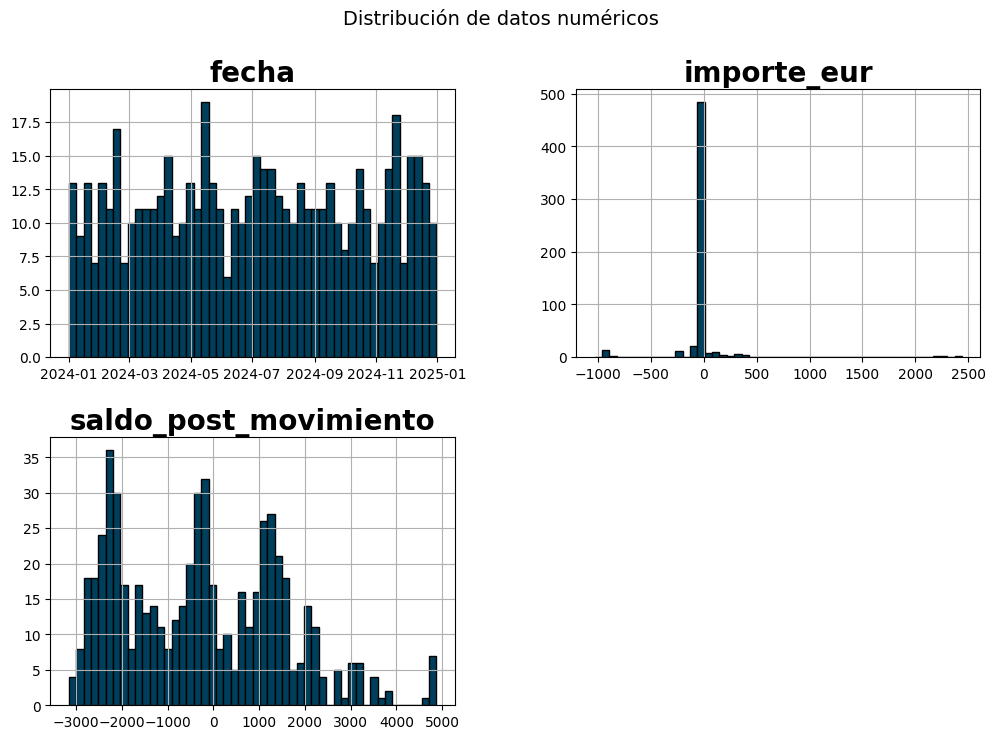

In [15]:
df.hist(figsize=(12,8), bins= 50, edgecolor = "black")
plt.suptitle("Distribución de datos numéricos", fontsize = 14)
plt.ylabel("Cantidad de movimientos")
plt.show()

En el grafico de importe_eur:
* la mayoria de los importes estan cerca del 0
* hay colas largas positivas y negativas
* existen movimientos grandes pocos frecuentes a analizar.


En el saldo_post_movimiento:
* Hay una zona negativa muy notoria
* El saldo negativo ocurre muchas veces
* Presenta alerta de riesgos

### Detección de Outliers

In [16]:
from src.outliers import outliers_iqr


lim_inf,lim_sup,outliers_importe = outliers_iqr(df,"importe_eur")
outliers_importe

Los límites de los outliers son: -93.4 y 21.51


,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_movimiento_general
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,None,gasto extraordinario
8,2024-01-05,Gasto,Alquiler,-900.00,3860.87,Cargo Alquiler,Débito,January,Friday,None,fijo
96,2024-03-05,Gasto,Alquiler,-900.00,2080.68,Cargo Alquiler,Débito,March,Tuesday,None,fijo
51,2024-02-05,Gasto,Alquiler,-900.00,2053.80,Cargo Alquiler,Débito,February,Monday,None,fijo
192,2024-05-05,Gasto,Alquiler,-900.00,362.51,Cargo Alquiler,Débito,May,Sunday,None,fijo
...,...,...,...,...,...,...,...,...,...,...,...
477,2024-11-01,Ingreso,Salario,2280.93,-625.19,Nómina mensual,Transferencia,November,Friday,Saldo negativo,ingreso de dinero
432,2024-10-01,Ingreso,Salario,2345.26,-814.34,Nómina mensual,Transferencia,October,Tuesday,Saldo negativo,ingreso de dinero
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,None,ingreso de dinero
188,2024-05-01,Ingreso,Salario,2427.84,2253.35,Nómina mensual,Transferencia,May,Wednesday,None,ingreso de dinero


In [17]:
cantidad_gastos_outlies = (outliers_importe["importe_eur"]<0).sum()
print(f'Cantidad de movimientos de gastos altos: {cantidad_gastos_outlies}')

Cantidad de movimientos de gastos altos: 37


In [18]:
cantidad_ingresos_outlies = (outliers_importe["importe_eur"]>0).sum()
print(f'Cantidad de movimientos de ingresos altos: {cantidad_ingresos_outlies}')

Cantidad de movimientos de ingresos altos: 44


Hay mas importes extraordinarios positivos que negativos, tenemos que estudiar si esos importes son de mayor impacto o no sobre el saldo. 

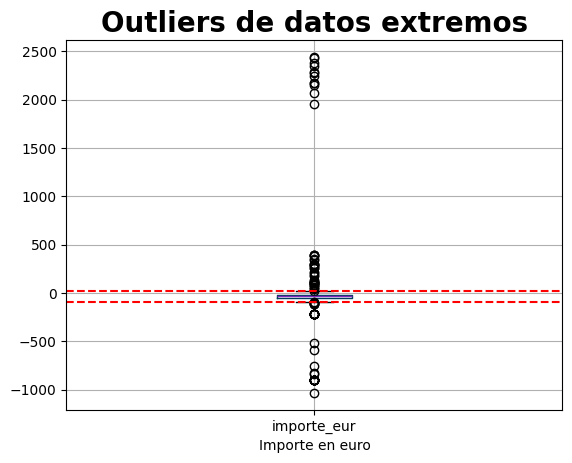

In [19]:
df.boxplot(column="importe_eur")
plt.title("Outliers de datos extremos")
plt.axhline(lim_inf, color="red", linestyle="--")
plt.axhline(lim_sup, color="red", linestyle="--")
plt.xlabel("Importe en euro")
plt.show()


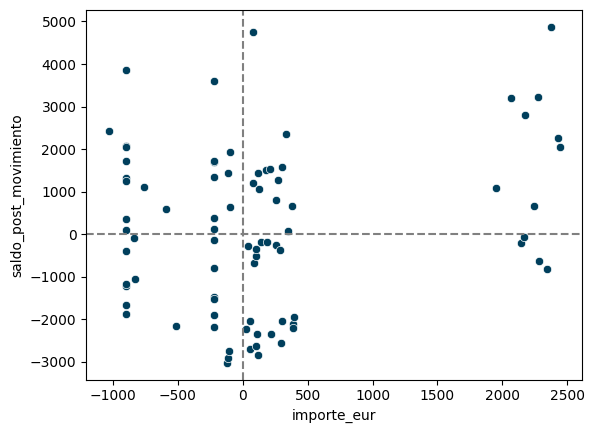

In [20]:
sns.scatterplot(
    data=outliers_importe,
    x="importe_eur",
    y="saldo_post_movimiento"
)
plt.axvline(0, color="grey", linestyle="--")
plt.axhline(0, color="grey", linestyle="--")
plt.show()


In [21]:
# Asignación usando .loc para evitar SettingWithCopyWarning
outliers_importe.loc[:, "signo"] = np.where(outliers_importe["importe_eur"] > 0, "Ingreso extremo", "Gasto extremo")

outliers_importe.groupby("signo")["saldo_post_movimiento"].agg(
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max",
    cantidad="count"
).round(2)

,promedio,mediana,minimo,maximo,cantidad
signo,,,,,
Gasto extremo,93.95,116.34,-3019.71,3860.87,37
Ingreso extremo,136.67,-178.36,-2836.29,4874.51,44


Vemos que cuando el cliente a pesar de tener un gasto grande, por tener anteriormente una cantidad de saldo considerable, en promedio termina en positivo. Esto quiere decir que al momento de tener ese gasto, el cliente era conciente del dinero que disponia.
Pero a pesar de tener ingresos grandes, tambien presenta momentos donde el saldo lo tiene en negativo por lo que hay en un momento de su saldo, que no pudo saldar los gastos grandes.

In [22]:
outliers_importe["descripcion"].unique()

array(['Compra excepcional', 'Cargo Alquiler', 'Cargo Préstamo personal',
       'Bizum enviado', 'Bizum recibido', 'Ingreso puntual',
       'Nómina mensual'], dtype=object)

In [23]:
outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_movimiento_general,signo
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,None,gasto extraordinario,Gasto extremo
191,2024-05-03,Gasto,Gasto extraordinario,-897.18,1262.51,Compra excepcional,Tarjeta,May,Friday,None,gasto extraordinario,Gasto extremo
177,2024-04-25,Gasto,Gasto extraordinario,-838.60,-77.99,Compra excepcional,Tarjeta,April,Thursday,Saldo negativo,gasto extraordinario,Gasto extremo
322,2024-07-20,Gasto,Gasto extraordinario,-829.57,-1041.46,Compra excepcional,Tarjeta,July,Saturday,Saldo negativo,gasto extraordinario,Gasto extremo
30,2024-01-20,Gasto,Gasto extraordinario,-759.67,1120.75,Compra excepcional,Tarjeta,January,Saturday,None,gasto extraordinario,Gasto extremo
294,2024-07-06,Gasto,Gasto extraordinario,-593.82,591.62,Compra excepcional,Tarjeta,July,Saturday,None,gasto extraordinario,Gasto extremo
403,2024-09-10,Gasto,Gasto extraordinario,-517.08,-2159.11,Compra excepcional,Tarjeta,September,Tuesday,Saldo negativo,gasto extraordinario,Gasto extremo


In [24]:
sumatoria_compra_excepcional = round(outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]["importe_eur"].sum(),2)

print(f'La sumatoria de los cargos excepcionales es de:  {sumatoria_compra_excepcional}€')

La sumatoria de los cargos excepcionales es de:  -5469.84€


Presenta varios cargos excepcionales. Los cuales los mas preocupantes son cuando su saldo pasa a ser negativo.

In [25]:
gastos_fijos = outliers_importe.groupby("tipo_movimiento_general")["importe_eur"].sum()
gastos_fijos

tipo_movimiento_general
fijo                   -13440.00
gasto extraordinario    -5469.84
ingreso de dinero       32490.09
sin definir                60.73
Name: importe_eur, dtype: float64

In [26]:
f"El cliente presenta gastos fijos durante el año de: {gastos_fijos.fijo.sum()} €"

'El cliente presenta gastos fijos durante el año de: -13440.0 €'

### Análisis categoria

In [27]:
#Vemos la cantidad de movimientos de gastos por categoria
categoria_gasto = df[df["importe_eur"]<0]["categoria"].value_counts().reset_index()
categoria_gasto

,categoria,count
0,Alimentación,141
1,Transporte,79
2,Restaurantes,54
3,Ocio,38
4,Otros,36
5,Ropa,28
6,Salud,28
7,Bizum,16
8,Educación,13
9,Alquiler,12


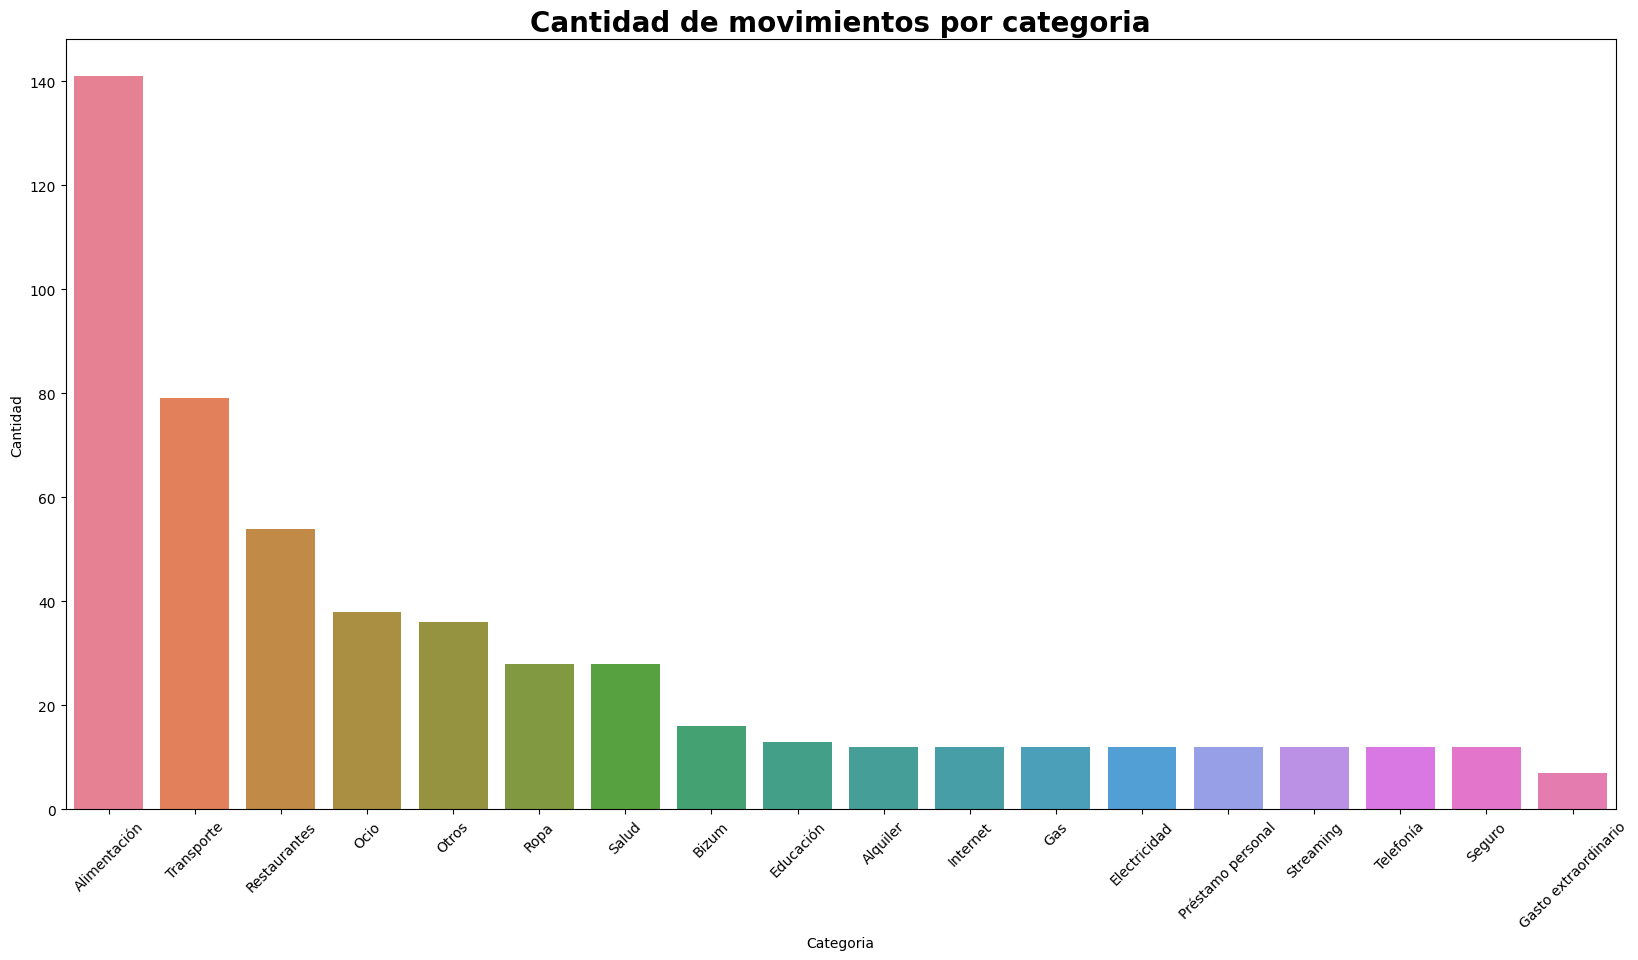

In [28]:
plt.figure(figsize = (20,10))
sns.barplot(data=categoria_gasto,x="categoria", y="count", hue="categoria")
plt.title("Cantidad de movimientos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Cantidad")
plt.xticks(rotation= 45)
plt.savefig(outdir / "cantidad_movimientos_por_categoria.png")
plt.show()
plt.close()

Vemos que hay una amplia diferecia con respecto a la alimentación en la cantidad de movimientos en los gastos.
Esto muestra cantidad de movimientos, no representa monetariamente.

In [29]:
#obtener top por gasto absoluto y ordenar de mayor a menor
gasto_por_categoria = df[df["importe_eur"]<0].groupby("categoria")["importe_eur"].sum().abs().sort_values(ascending=False).reset_index()
top5_gasto_personal = gasto_por_categoria.head(5)

TOP 5 de gastos durante el año.

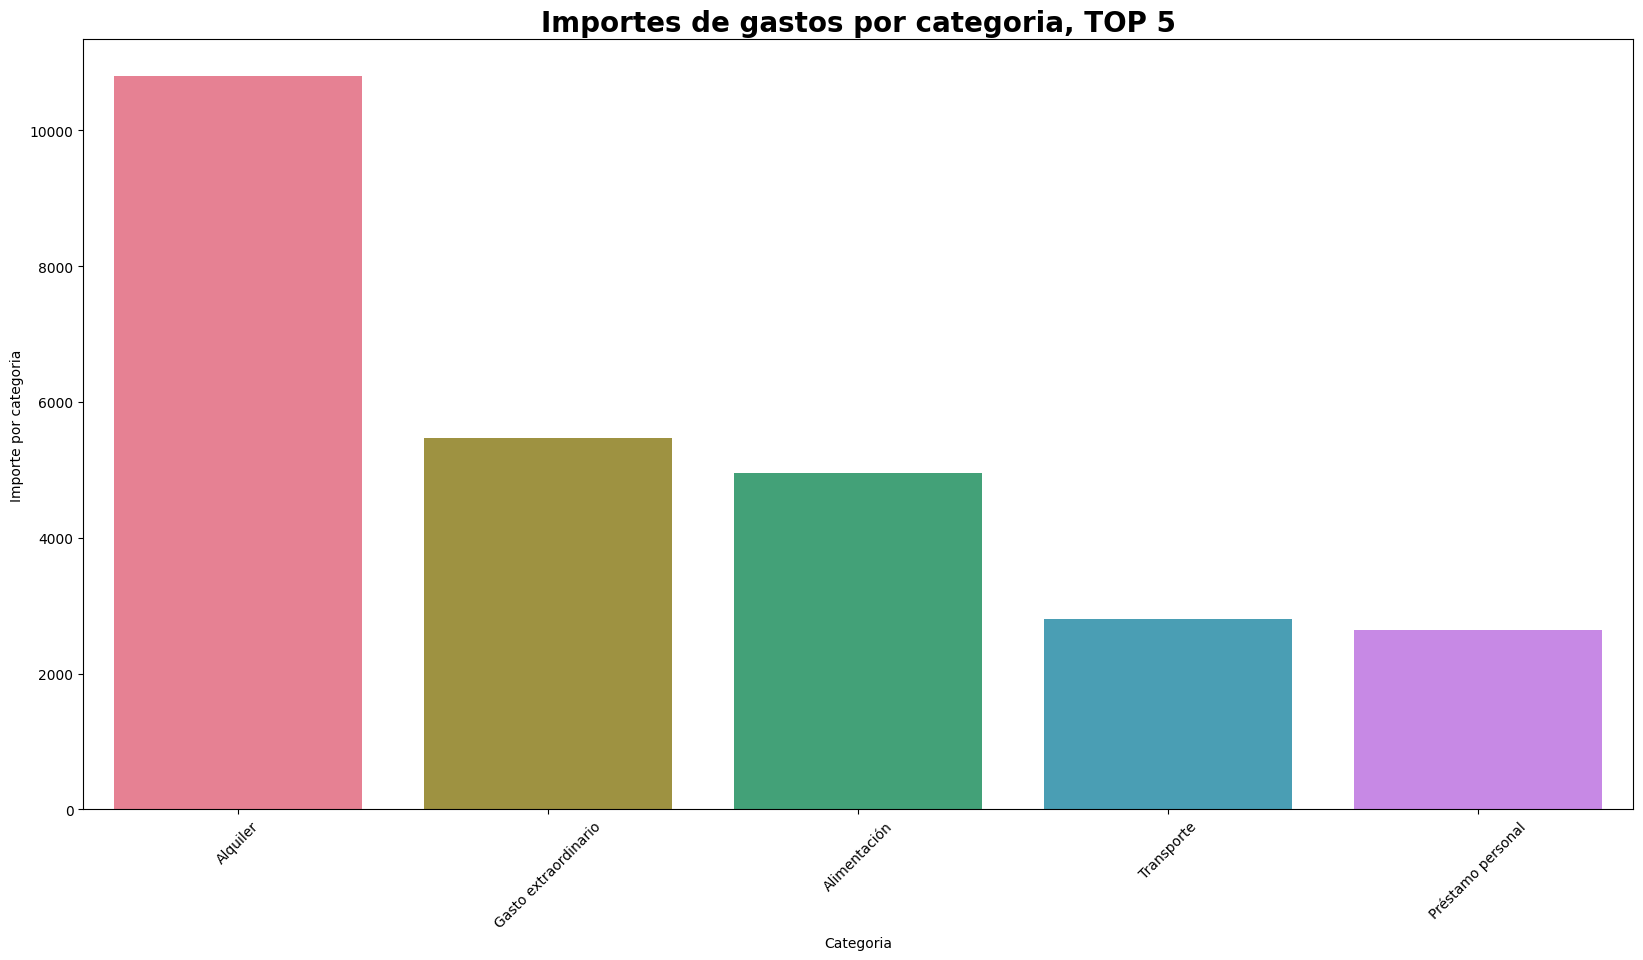

In [30]:
plt.figure(figsize=(20,10))
sns.barplot(data=top5_gasto_personal, x="categoria", y="importe_eur", hue="categoria")
plt.title("Importes de gastos por categoria, TOP 5")
plt.xlabel("Categoria")
plt.ylabel("Importe por categoria")
plt.xticks(rotation=45)
plt.savefig(outdir / "Top5_importes_de_gastos_por_categoria.png")
plt.show()
plt.close()

Top 5 de las categorias que más gastos generan, algunos son gastos fijos y otros variables.

### Análisis por mes

In [31]:
#agrupamos unicamente los gastos por mes.

gastos_por_mes = df[df["importe_eur"]<0].groupby("mes")["importe_eur"].sum().abs()


#agrupamos unicamente los ingresos por mes
ingresos_por_mes = df[df["importe_eur"]>0].groupby("mes")["importe_eur"].sum()

#creamos un dataframe con los gastos e ingresos
resumen_mensual = pd.DataFrame({
    "gastos": gastos_por_mes,
    "ingresos": ingresos_por_mes
})

#creamos un melt, para poder graficar luego un barplot donde compare cada mes y sea mas facil visualmente.
resumen_mensual = (
    resumen_mensual.reset_index().melt(
        id_vars="mes",
        value_vars=["gastos","ingresos"],
        var_name="tipo",
        value_name="monto"
    )
)

sorted(resumen_mensual["mes"])
resumen_mensual

C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\1730455786.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gastos_por_mes = df[df["importe_eur"]<0].groupby("mes")["importe_eur"].sum().abs()
C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\1730455786.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ingresos_por_mes = df[df["importe_eur"]>0].groupby("mes")["importe_eur"].sum()


,mes,tipo,monto
0,January,gastos,4289.92
1,February,gastos,2673.04
2,March,gastos,2936.36
3,April,gastos,3470.69
4,May,gastos,3789.75
5,June,gastos,2112.87
6,July,gastos,4355.99
7,August,gastos,3030.26
8,September,gastos,3116.63
9,October,gastos,2498.79


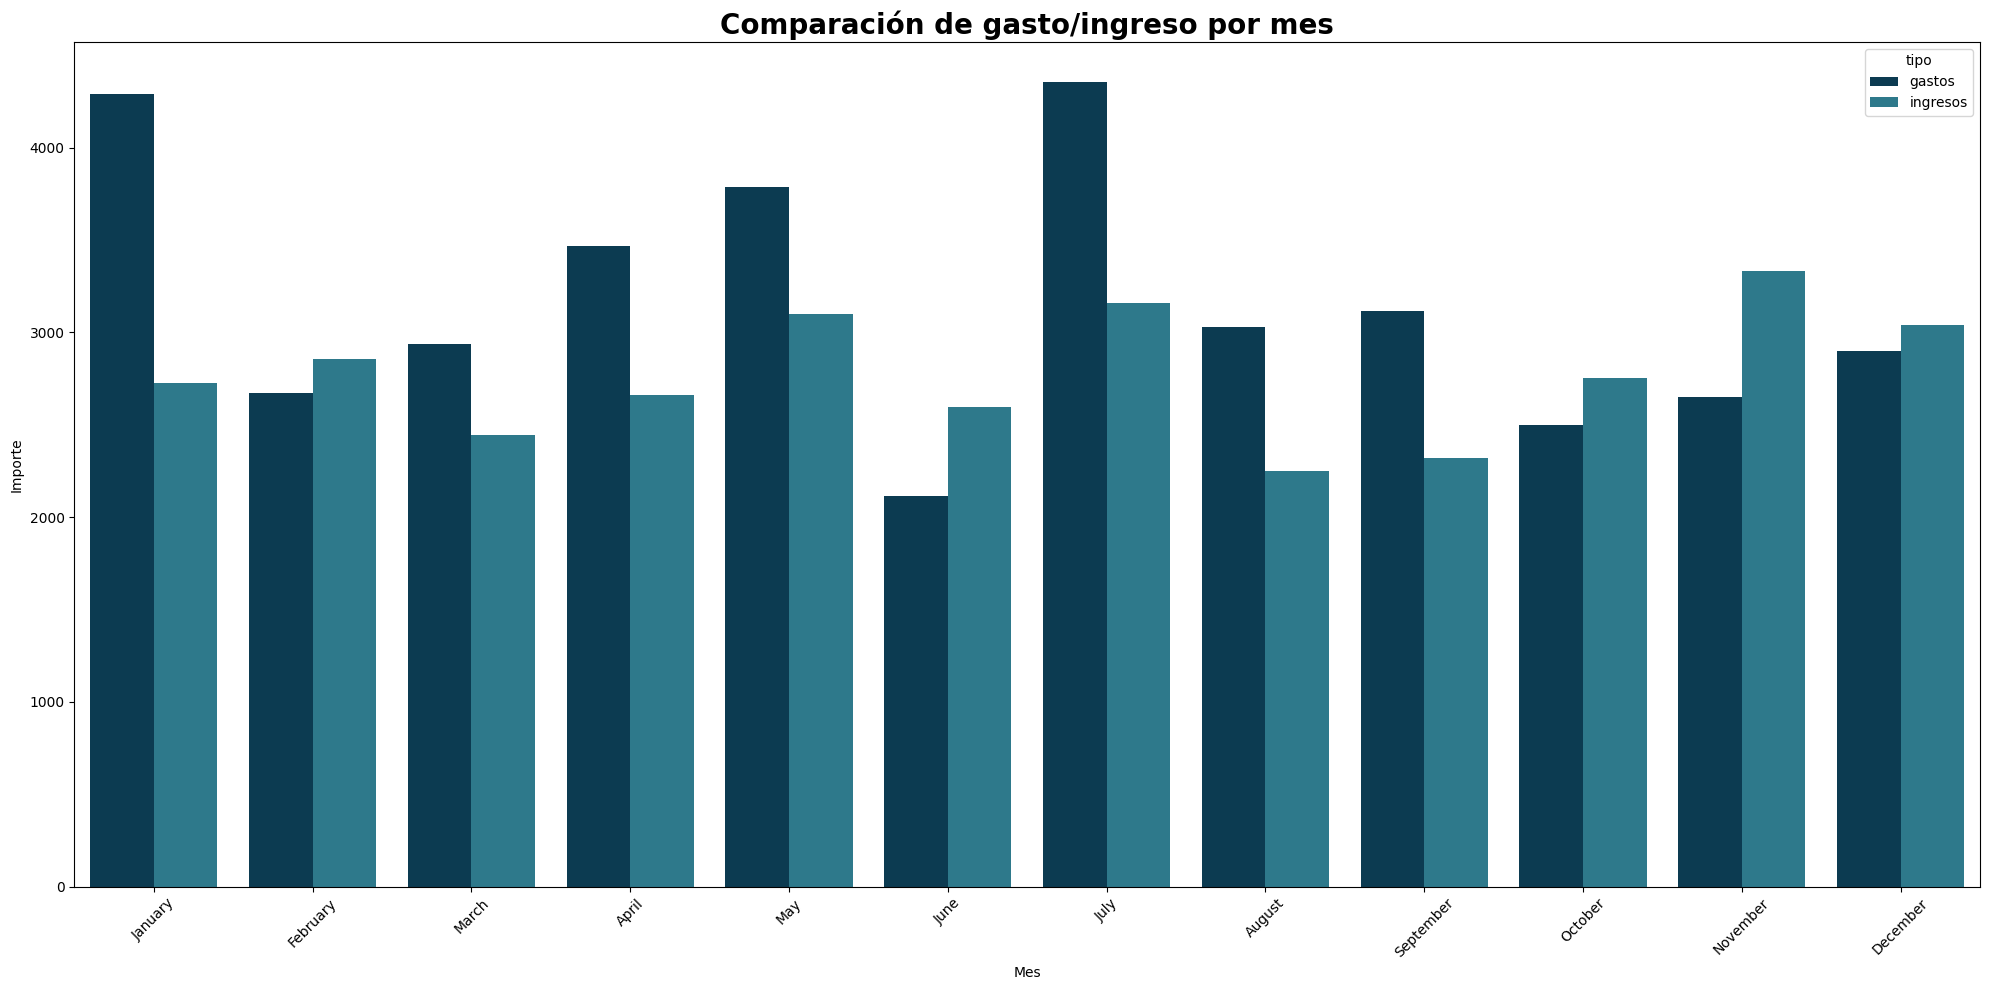

In [32]:
plt.figure(figsize=(20,10))
sns.barplot(data=resumen_mensual, x="mes", y="monto", hue="tipo")
plt.title("Comparación de gasto/ingreso por mes")
plt.xlabel("Mes")
plt.ylabel("Importe")
plt.xticks(rotation= 45)
plt.tight_layout()
plt.savefig(outdir / "comparacion_gasto_ingreso_por_mes.png")
plt.show()
plt.close()


Vemos una clara tendencia de gastar más de lo que ingresa, por lo que el ahorro se dificulta.
Sin embargo, hay una tendencia creciente a partir del mes de octubre sobre lo que ingresa a comparación de los gastos. Es un periodo de tiempo a analizar, por que se debe esa bajada en los gastos?

In [33]:
#Se crea un dataframe que agrupe por mes, con las columnas definidos en ingresos, gastos y saldo final. Se chequea lo que se ingreso por mes y lo que se gasto, para sacar la diferencia.

df_mes_ingreso_y_gasto = df.groupby("mes").agg(
    ingresos=("importe_eur", lambda x: x[x>0].sum()),
    gastos=("importe_eur", lambda x: x[x<0].sum()),
    saldo_final=("saldo_post_movimiento", "last")
)


df_mes_ingreso_y_gasto


C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\4290484632.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mes_ingreso_y_gasto = df.groupby("mes").agg(


,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-4289.92,936.50
February,2859.07,-2673.04,1122.51
March,2446.67,-2936.36,632.83
April,2663.34,-3470.69,-174.49
May,3097.48,-3789.75,-866.75
June,2598.59,-2112.87,-381.03
July,3157.15,-4355.99,-1579.89
August,2248.55,-3030.26,-2361.59
September,2318.62,-3116.63,-3159.60


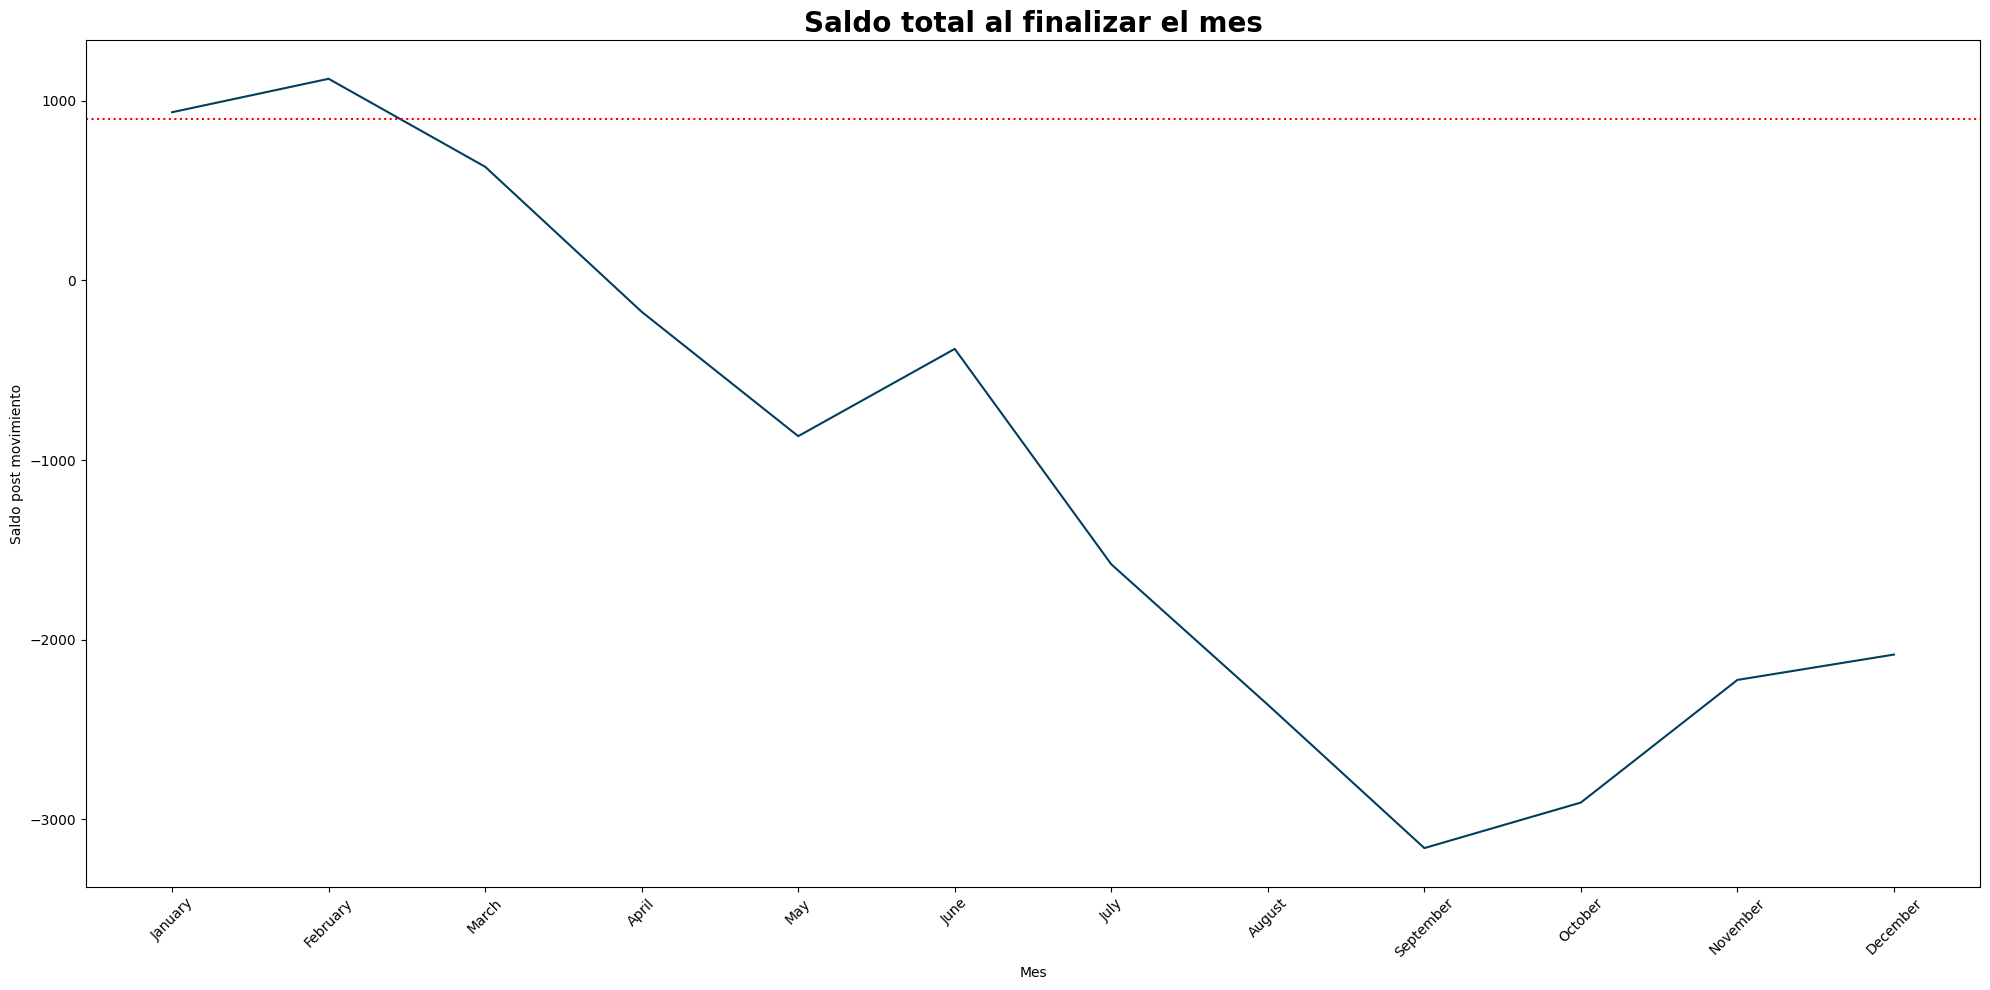

In [34]:
plt.figure(figsize=(20,10))
sns.lineplot(data= df_mes_ingreso_y_gasto, x= "mes", y= "saldo_final")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Saldo total al finalizar el mes")
plt.axhline(y=saldo_seguridad,color="red", linestyle= ':' )
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig(outdir / "saldo_total_fonalizar_mes.png")
plt.show()
plt.close()

Vemos una clara descendencia del salario al finalizar cada mes. Hay un ligero repunte en el mes de junio que luego vuelve a caer.
A partir de Septiembre, comienza un nuevo crecimiento del saldo.
Hay que analizar los gastos por categorias desde junio a septiembre para saber por que baja mucho el saldo y no logra repuntar, que tipos de gastos se hizo? 
Luego en septiembre se vio un repunte hacia arriba? por que se debe esto? que gasto no se esta haciendo? puede ser la finalizacion de un prestamo? o ha ingresado mas dinero de lo habitual?
Lo más preocupante es que estamos lejos del saldo mínimo de seguridad que quiere el cliente.

In [35]:
#saco la diferencia de ingresos y gastos (es una suma ya que los gastos aparecen en negativos)

df_diferencia = df_mes_ingreso_y_gasto["ingresos"] + df_mes_ingreso_y_gasto["gastos"]
df_diferencia = df_diferencia.reset_index(name="Diferencia ingreso - gasto")
df_diferencia

,mes,Diferencia ingreso - gasto
0,January,-1563.52
1,February,186.03
2,March,-489.69
3,April,-807.35
4,May,-692.27
5,June,485.72
6,July,-1198.84
7,August,-781.71
8,September,-798.01
9,October,253.49


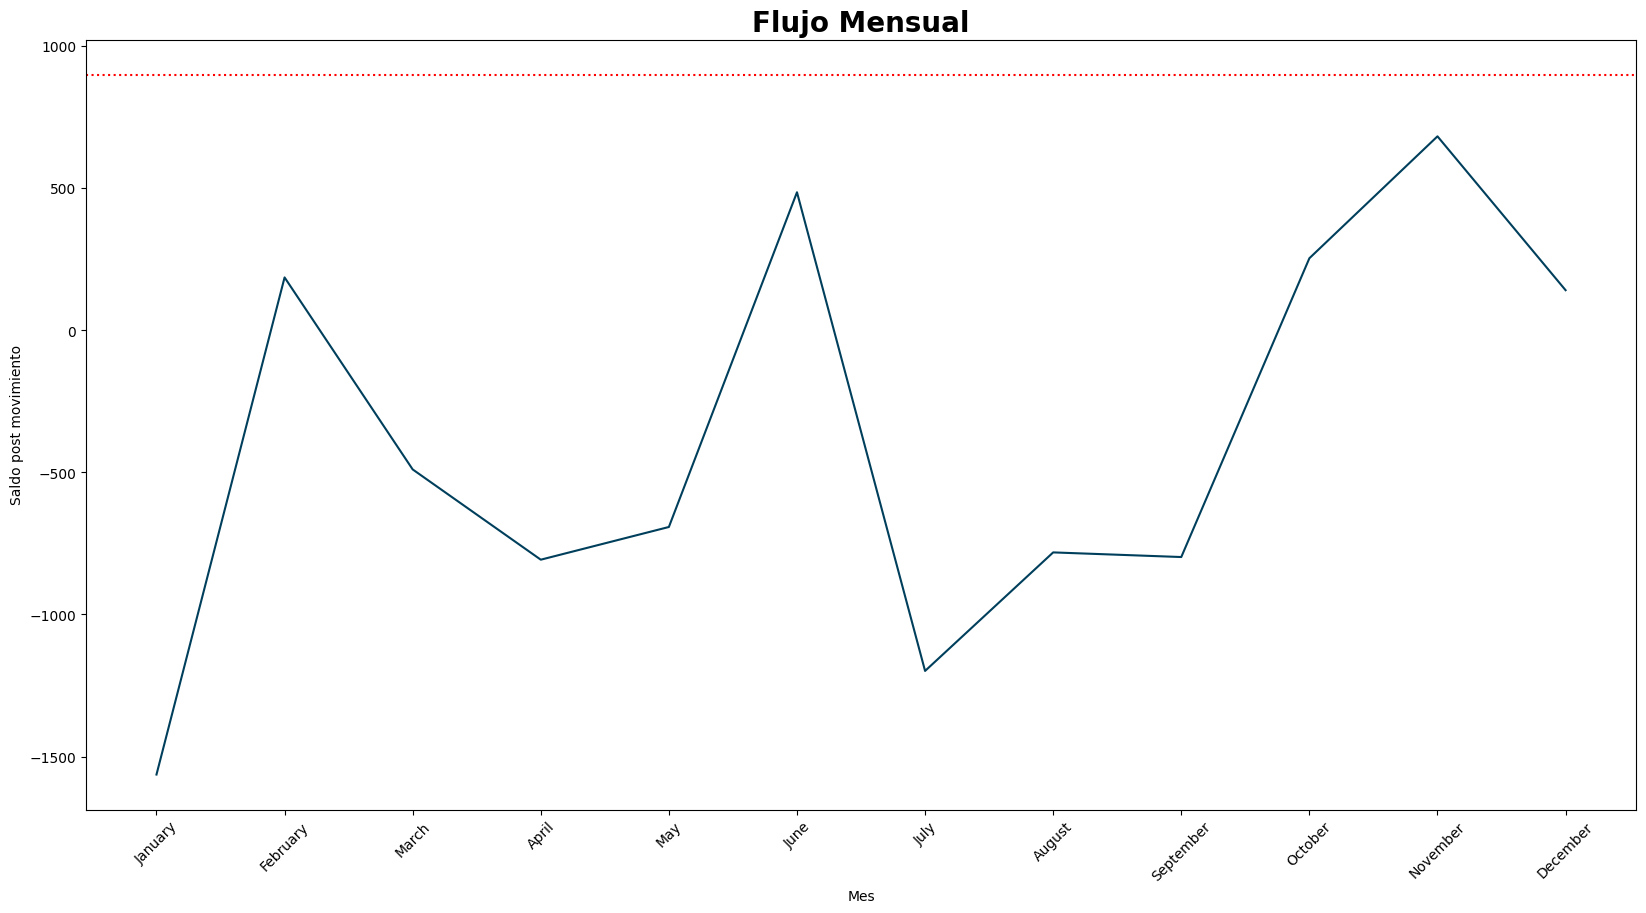

In [36]:
plt.figure(figsize=(20,10))
sns.lineplot(data= df_diferencia, x= "mes", y= "Diferencia ingreso - gasto")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Flujo Mensual")
plt.axhline(y=saldo_seguridad,color= "red", linestyle= ":")
plt.xticks(rotation = 45)
plt.savefig(outdir / "flujo_mensual_diferencia_ingreso_gasto.png")
plt.show()
plt.close()

Vemos que el cliente tiene varios repuntes de su saldo, donde enero y julio son los meses que peor caida presente. Hay que averiguar que categoria es la culpable en estos 2 meses para saber donde poder interferir para mejorar su ahorro.
Ningun mes supera ni alncanza el saldo de seguridad.

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?

In [37]:
#para ver el saldo final por mes
df_mes_ingreso_y_gasto

,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-4289.92,936.50
February,2859.07,-2673.04,1122.51
March,2446.67,-2936.36,632.83
April,2663.34,-3470.69,-174.49
May,3097.48,-3789.75,-866.75
June,2598.59,-2112.87,-381.03
July,3157.15,-4355.99,-1579.89
August,2248.55,-3030.26,-2361.59
September,2318.62,-3116.63,-3159.60


In [38]:
#dataframe de gastos agrupados por categoria y la suma de sus importes.

df_gastos_categoria = df[df["importe_eur"]<0].groupby(["categoria"])["importe_eur"].sum().reset_index().rename(columns={"importe_eur":"gastos_categoria"})

df_gastos_categoria.sort_values(by="gastos_categoria")

,categoria,gastos_categoria
1,Alquiler,-10800.00
6,Gasto extraordinario,-5469.84
0,Alimentación,-4948.44
17,Transporte,-2799.08
10,Préstamo personal,-2640.00
11,Restaurantes,-1747.68
8,Ocio,-1303.70
9,Otros,-1302.63
2,Bizum,-1119.30
13,Salud,-1035.79


In [39]:
#Corroboro la cantidad en dinero de gastos por categoria. Modificamos el nombre de la columna importe_eur en gastos para mejor definición

gastos_cat_por_mes = df[df["importe_eur"]<0].groupby(["categoria","mes"])["importe_eur"].sum().reset_index().rename(columns={"importe_eur":"gastos_categoria"})
gastos_cat_por_mes = pd.DataFrame(gastos_cat_por_mes)
gastos_cat_por_mes

C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\2317184058.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gastos_cat_por_mes = df[df["importe_eur"]<0].groupby(["categoria","mes"])["importe_eur"].sum().reset_index().rename(columns={"importe_eur":"gastos_categoria"})


,categoria,mes,gastos_categoria
0,Alimentación,January,-355.83
1,Alimentación,February,-333.02
2,Alimentación,March,-435.51
3,Alimentación,April,-341.90
4,Alimentación,May,-298.83
...,...,...,...
211,Transporte,August,-250.14
212,Transporte,September,-169.48
213,Transporte,October,-134.88
214,Transporte,November,-239.09


In [40]:
#Uno los 2 dataframe para tener una mejor visualización de los datos
ingr_gas_por_mes = pd.merge(df_mes_ingreso_y_gasto, gastos_cat_por_mes, how="inner", on="mes")

ingr_gas_por_mes

,mes,ingresos,gastos,saldo_final,categoria,gastos_categoria
0,January,2726.4,-4289.92,936.50,Alimentación,-355.83
1,January,2726.4,-4289.92,936.50,Alquiler,-900.00
2,January,2726.4,-4289.92,936.50,Bizum,0.00
3,January,2726.4,-4289.92,936.50,Educación,-99.63
4,January,2726.4,-4289.92,936.50,Electricidad,-70.00
...,...,...,...,...,...,...
211,December,3040.6,-2899.48,-2082.44,Salud,-52.59
212,December,3040.6,-2899.48,-2082.44,Seguro,-45.00
213,December,3040.6,-2899.48,-2082.44,Streaming,-25.00
214,December,3040.6,-2899.48,-2082.44,Telefonía,-35.00


In [41]:
#Se crea una columna con el nombre de porcentaje. Muestra el porcentaje que representa por mes, los gastos de la categoria sobre sus ingresos.
if ingr_gas_por_mes["ingresos"].any() != 0:
    ingr_gas_por_mes["porcentaje_gasto_categoria"] = round((ingr_gas_por_mes["gastos_categoria"] / ingr_gas_por_mes["ingresos"]) * 100, 2).abs()

ingr_gas_por_mes

,mes,ingresos,gastos,saldo_final,categoria,gastos_categoria,porcentaje_gasto_categoria
0,January,2726.4,-4289.92,936.50,Alimentación,-355.83,13.05
1,January,2726.4,-4289.92,936.50,Alquiler,-900.00,33.01
2,January,2726.4,-4289.92,936.50,Bizum,0.00,0.00
3,January,2726.4,-4289.92,936.50,Educación,-99.63,3.65
4,January,2726.4,-4289.92,936.50,Electricidad,-70.00,2.57
...,...,...,...,...,...,...,...
211,December,3040.6,-2899.48,-2082.44,Salud,-52.59,1.73
212,December,3040.6,-2899.48,-2082.44,Seguro,-45.00,1.48
213,December,3040.6,-2899.48,-2082.44,Streaming,-25.00,0.82
214,December,3040.6,-2899.48,-2082.44,Telefonía,-35.00,1.15


In [42]:
#Se realiza un TOP 5 de los porcentajes de gastos que mas influyen sobre los ingresos

#top de categoria que mas influye
top_categoria_porcentaje = ingr_gas_por_mes.groupby("categoria")["porcentaje_gasto_categoria"].mean().sort_values(ascending=False).head(5).index


#si integra el top de categoria que lo agregue al df_plot
df_plot = ingr_gas_por_mes[ingr_gas_por_mes["categoria"].isin(top_categoria_porcentaje)]
df_plot

,mes,ingresos,gastos,saldo_final,categoria,gastos_categoria,porcentaje_gasto_categoria
0,January,2726.40,-4289.92,936.50,Alimentación,-355.83,13.05
1,January,2726.40,-4289.92,936.50,Alquiler,-900.00,33.01
6,January,2726.40,-4289.92,936.50,Gasto extraordinario,-1793.59,65.79
10,January,2726.40,-4289.92,936.50,Préstamo personal,-220.00,8.07
17,January,2726.40,-4289.92,936.50,Transporte,-218.91,8.03
18,February,2859.07,-2673.04,1122.51,Alimentación,-333.02,11.65
19,February,2859.07,-2673.04,1122.51,Alquiler,-900.00,31.48
24,February,2859.07,-2673.04,1122.51,Gasto extraordinario,0.00,0.00
28,February,2859.07,-2673.04,1122.51,Préstamo personal,-220.00,7.69
35,February,2859.07,-2673.04,1122.51,Transporte,-164.69,5.76


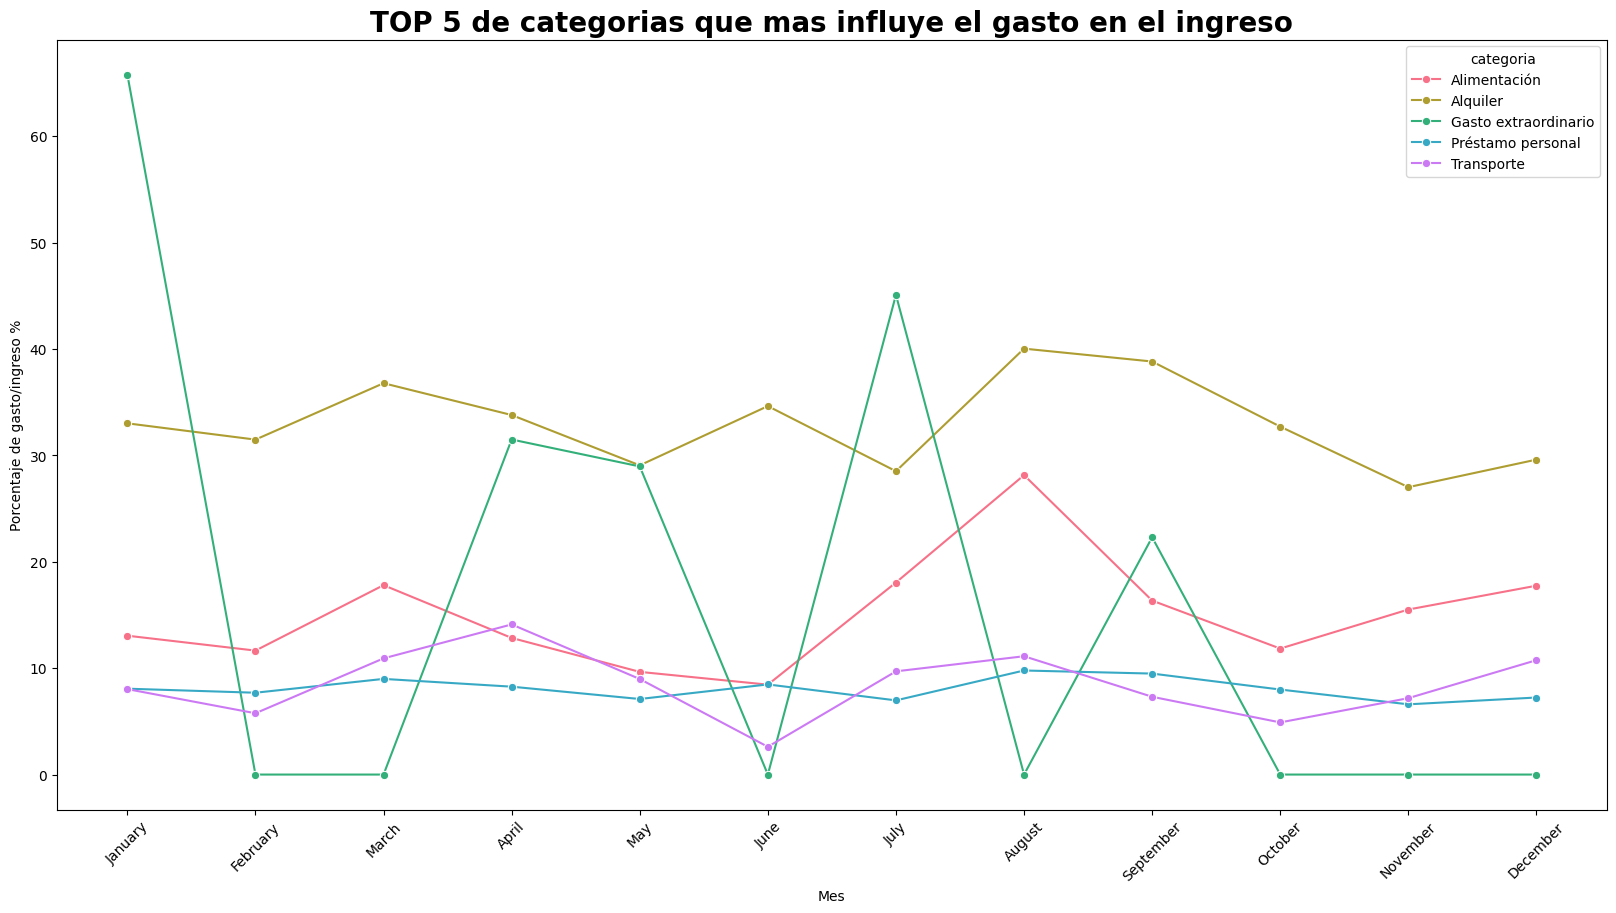

In [43]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df_plot, x="mes", y="porcentaje_gasto_categoria",hue="categoria", marker="o")
plt.title("TOP 5 de categorias que mas influye el gasto en el ingreso")
plt.xlabel("Mes")
plt.ylabel("Porcentaje de gasto/ingreso %")
plt.xticks(rotation=45)
plt.savefig(outdir / "Top5_categorias_inlfuyentes_en_ingreso.png")
plt.show()
plt.close()

El gráfico muestra que los picos en el porcentaje del ingreso destinado a gastos se producen principalmente en los meses en los que aparecen gastos extraordinarios.
Estos eventos generan el mayor impacto negativo sobre el saldo mensual, debido a su carácter puntual y no recurrente.

En contraste, el alquiler representa de forma consistente el mayor porcentaje del gasto mensual; sin embargo, su impacto es estructural y previsible, ya que se trata de un gasto fijo.

La alimentación corresponde a un gasto recurrente, aunque se observa un incremento significativo en el mes de agosto. Este aumento podría estar asociado a factores estacionales, como vacaciones, mayor consumo fuera del hogar o gastos extraordinarios vinculados al período.

Por último, el préstamo personal y el transporte presentan una evolución relativamente lineal, lo que indica que su porcentaje sobre el ingreso se mantiene estable a lo largo del tiempo y no genera desequilibrios significativos en el presupuesto mensual.

### Gasto acumulativo por tipo_gasto

In [44]:
#agrupo tipo gasto y su cantidad de importe, para ver que tipo de gasto general tiene mas cantidad.

df_tipo_gasto = df.groupby("tipo_movimiento_general")["importe_eur"].sum().reset_index()
df_tipo_gasto

,tipo_movimiento_general,importe_eur
0,fijo,-17106.72
1,gasto extraordinario,-10813.90
2,gasto recurrente,-8783.31
3,ingreso de dinero,32490.09
4,sin definir,-368.63


### Gasto en Alimentación

In [45]:
gasto_alimentacion_por_dia = df[df["categoria"] == "Alimentación"].groupby("dia")["importe_eur"].sum().reset_index()
gasto_alimentacion_por_dia.sort_values(by="importe_eur")

,dia,importe_eur
5,Tuesday,-865.07
2,Saturday,-834.27
0,Friday,-729.24
3,Sunday,-692.88
1,Monday,-636.46
4,Thursday,-613.22
6,Wednesday,-577.30


In [46]:
media_alimentacion = gasto_alimentacion_por_dia["importe_eur"].mean()

print(f'La media de gasto entre el maximo y el minimo de lo gastado en alimentación es: {round(media_alimentacion,2)}')



La media de gasto entre el maximo y el minimo de lo gastado en alimentación es: -706.92


In [47]:
gasto_alimentacion_por_dia["porcentaje_a_ahorrar"] = round(((gasto_alimentacion_por_dia["importe_eur"] - media_alimentacion)/gasto_alimentacion_por_dia["importe_eur"]) * 100, 2)
gasto_alimentacion_por_dia

,dia,importe_eur,porcentaje_a_ahorrar
0,Friday,-729.24,3.06
1,Monday,-636.46,-11.07
2,Saturday,-834.27,15.26
3,Sunday,-692.88,-2.03
4,Thursday,-613.22,-15.28
5,Tuesday,-865.07,18.28
6,Wednesday,-577.30,-22.45


Los martes y los sabados, son los dias que más gasta a comparación de la media a gastar. Entre un 15% y 18%.

### Gráficos con movimientos óptimos

Se generaran graficos con movimientos optimos, sin gastos extraordinarios, préstamos y con la reducción de 15% en Alimentación.

In [48]:
#calculamos el ahorro anual de la reduccion de un 15% en alimentación.(multiplicar por 0.85 es igual)
gasto_alimentacion_anual = df_gastos_categoria[df_gastos_categoria["categoria"] == "Alimentación"]["gastos_categoria"]

diferencia_alimentacion_anual = gasto_alimentacion_anual * 0.85

ahorro_alimentacion = gasto_alimentacion_anual - diferencia_alimentacion_anual


#calcular el ahorro mensual de la reducción de un 15% n alimentación.


gasto_alimentacion_mensual = df[df["categoria"] == "Alimentación"]["importe_eur"]
diferencia_alimentacion_mensual = gasto_alimentacion_mensual  * 0.85


df_optimizado = df.copy()

df_optimizado.loc[df_optimizado["categoria"]=="Alimentación", "importe_eur"] = diferencia_alimentacion_mensual

df_optimizado.drop(df_optimizado[df_optimizado["categoria"] == "Gasto extraordinario"].index, inplace=True)

df_optimizado.drop(df_optimizado[df_optimizado["categoria"] == "Préstamo personal"].index, inplace=True)

df_optimizado["importe_eur"] = round(df_optimizado["importe_eur"],2)

saldo_inicial = df.iloc[0]["saldo_post_movimiento"]

# La primera fila mantiene su valor original
# Las demás se calculan acumulando desde la primera
df_optimizado.loc[1:, "saldo_post_movimiento"] = (
    df_optimizado.loc[0, "saldo_post_movimiento"] + 
    df_optimizado.loc[1:, "importe_eur"].cumsum()
)

df_optimizado.head(5)




,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_movimiento_general
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,None,ingreso de dinero
1,2024-01-01,Gasto,Transporte,-31.18,4843.33,Pago con tarjeta,Tarjeta,January,Monday,None,gasto recurrente
2,2024-01-02,Gasto,Alimentación,-49.67,4793.66,Pago con tarjeta,Tarjeta,January,Tuesday,None,gasto recurrente
3,2024-01-03,Gasto,Transporte,-8.37,4785.29,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente
4,2024-01-03,Gasto,Alimentación,-30.00,4755.29,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente


In [49]:
#comparo con el df original para ver las primeras 5 filas y sus cambios

df.head(5)

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,tipo_movimiento_general
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,None,ingreso de dinero
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta,January,Monday,None,gasto recurrente
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta,January,Tuesday,None,gasto recurrente
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta,January,Wednesday,None,gasto recurrente


In [50]:
#Se crea un dataframe que agrupe por mes, con las columnas definidos en ingresos, gastos y saldo final. Se chequea lo que se ingreso por mes y lo que se gasto, para sacar la diferencia.

df_mes_ingreso_y_gasto_optimizado = df_optimizado.groupby("mes").agg(
    ingresos=("importe_eur", lambda x: x[x>0].sum()),
    gastos=("importe_eur", lambda x: x[x<0].sum()),
    saldo_final=("saldo_post_movimiento", "last")
)

df_mes_ingreso_y_gasto_optimizado

C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\1951372561.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mes_ingreso_y_gasto_optimizado = df_optimizado.groupby("mes").agg(


,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-2222.95,3003.45
February,2859.07,-2403.09,3459.43
March,2446.67,-2651.03,3255.07
April,2663.34,-2360.81,3557.60
May,3097.48,-2627.75,4027.33
June,2598.59,-1859.94,4765.98
July,3157.15,-2627.12,5296.01
August,2248.55,-2715.34,4829.22
September,2318.62,-2322.69,4825.15


In [51]:
#comparo con el calculo del df original

df_mes_ingreso_y_gasto

,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-4289.92,936.50
February,2859.07,-2673.04,1122.51
March,2446.67,-2936.36,632.83
April,2663.34,-3470.69,-174.49
May,3097.48,-3789.75,-866.75
June,2598.59,-2112.87,-381.03
July,3157.15,-4355.99,-1579.89
August,2248.55,-3030.26,-2361.59
September,2318.62,-3116.63,-3159.60


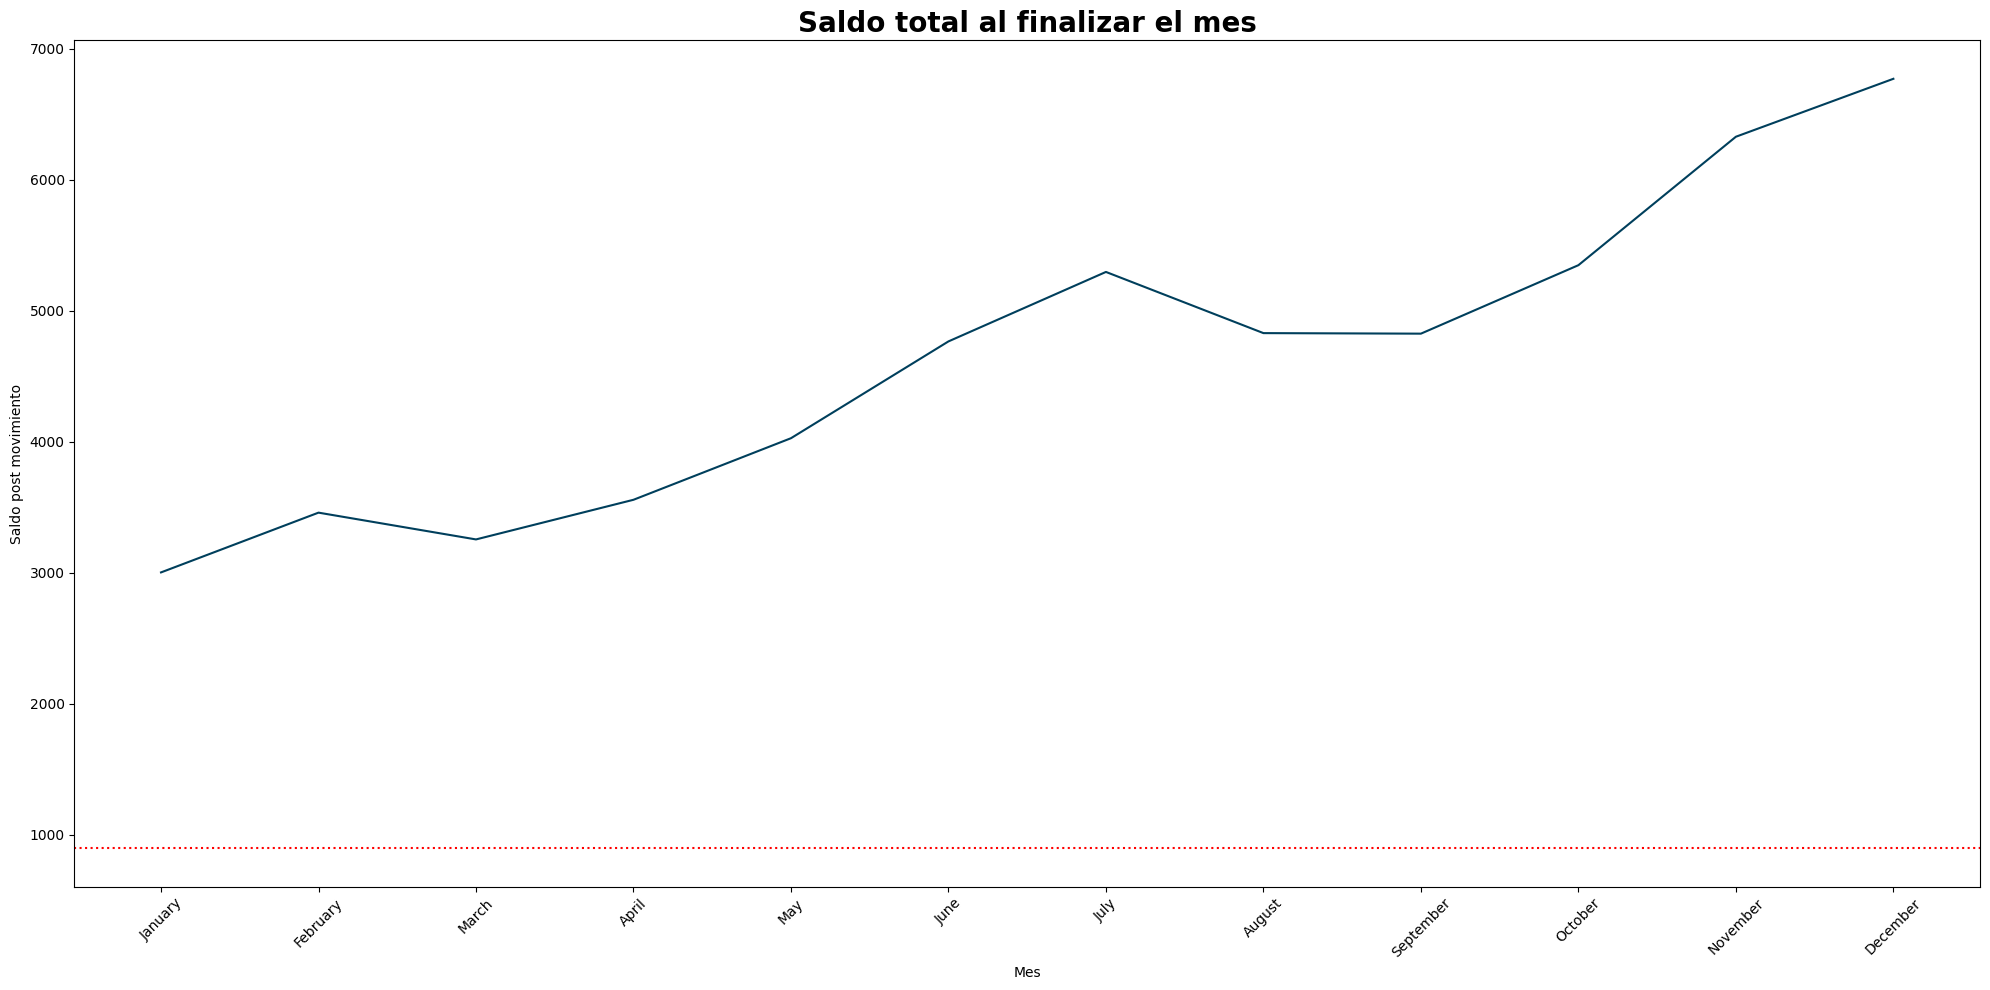

In [52]:
plt.figure(figsize=(20,10))
sns.lineplot(data= df_mes_ingreso_y_gasto_optimizado, x= "mes", y= "saldo_final")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Saldo total al finalizar el mes")
plt.axhline(y=saldo_seguridad,color="red", linestyle= ':' )
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig(outdir / "Saldo_total_finalizar_mes_optimizado.png")
plt.show()
plt.close()

Se confirma que el consumo que más influye en el saldo final del cliente son los gastos extraordinarios.
A pesar de eliminar el prestamos personal y reducir un 15% en alimentación, esos gastos extraordinarios son los que reducen de manera sustancial el saldo del cliente. 

### Investigamos como influye si esos gastos extraordinarios se reducen en un cierto porcentaje.

Posiblemente los gastos extraordinarios del cliente tengan un motivo en especial, por lo que investigaremos si al reducir esos gastos en diferentes porcentajes, sin restar los gastos del préstamo personal y agregando el ahorro del 15% en alimentación es posible llegar al saldo de seguridad

In [53]:
from src.funciones import calcular_porcentaje

#calculamos el ahorro anual de la reduccion de un 15% en alimentación.(multiplicar por 0.85 es igual)
gasto_alimentacion_anual = df_gastos_categoria[df_gastos_categoria["categoria"] == "Alimentación"]["gastos_categoria"]

diferencia_alimentacion_anual = calcular_porcentaje(gasto_alimentacion_anual,0.85)

ahorro_alimentacion = gasto_alimentacion_anual - diferencia_alimentacion_anual


#calcular el ahorro mensual de la reducción de un 15% n alimentación.


gasto_alimentacion_mensual = df[df["categoria"] == "Alimentación"]["importe_eur"]
diferencia_alimentacion_mensual = calcular_porcentaje(gasto_alimentacion_mensual,0.85)



porcentajes_reduccion = [0.25,0.50,0.75]

gasto_extraordinario = df[df["categoria"] == "Gasto extraordinario"]["importe_eur"]

dfs_optimizados = {}

for por in porcentajes_reduccion:
    df_optimizado_gasto_ext_por = df.copy()
    
    gasto_extraordinario_por_porcentaje = calcular_porcentaje(gasto_extraordinario,por)
    
    #calcular el 15% de alimentacion
    df_optimizado_gasto_ext_por.loc[df_optimizado_gasto_ext_por["categoria"]=="Alimentación", "importe_eur"] = diferencia_alimentacion_mensual

    #calcular el porcentaje de reduccion en gasto extraordinario
    df_optimizado_gasto_ext_por.loc[df_optimizado_gasto_ext_por["categoria"] == "Gasto extraordinario", "importe_eur"] = gasto_extraordinario_por_porcentaje
    
    df_optimizado_gasto_ext_por["importe_eur"] = round(df_optimizado_gasto_ext_por["importe_eur"],2)
    
    saldo_inicial = df.iloc[0]["saldo_post_movimiento"]

    # La primera fila mantiene su valor original
    # Las demás se calculan acumulando desde la primera
    df_optimizado_gasto_ext_por.loc[1:, "saldo_post_movimiento"] = (
        df_optimizado_gasto_ext_por.loc[0, "saldo_post_movimiento"] + 
        df_optimizado_gasto_ext_por.loc[1:, "importe_eur"].cumsum()
    )
    
    dfs_optimizados[por] = df_optimizado_gasto_ext_por




=== Escenario con el 25% de gasto extraordinario ===


C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\3821141133.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mes_gas_ext = df_opt.groupby("mes").agg(


,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-2891.35,2335.05
February,2859.07,-2623.09,2571.03
March,2446.67,-2871.03,2146.67
April,2663.34,-2790.46,2019.55
May,3097.48,-3072.05,2044.98
June,2598.59,-2079.94,2563.63
July,3157.15,-3202.97,2517.81
August,2248.55,-2935.34,1831.02
September,2318.62,-2671.96,1477.68


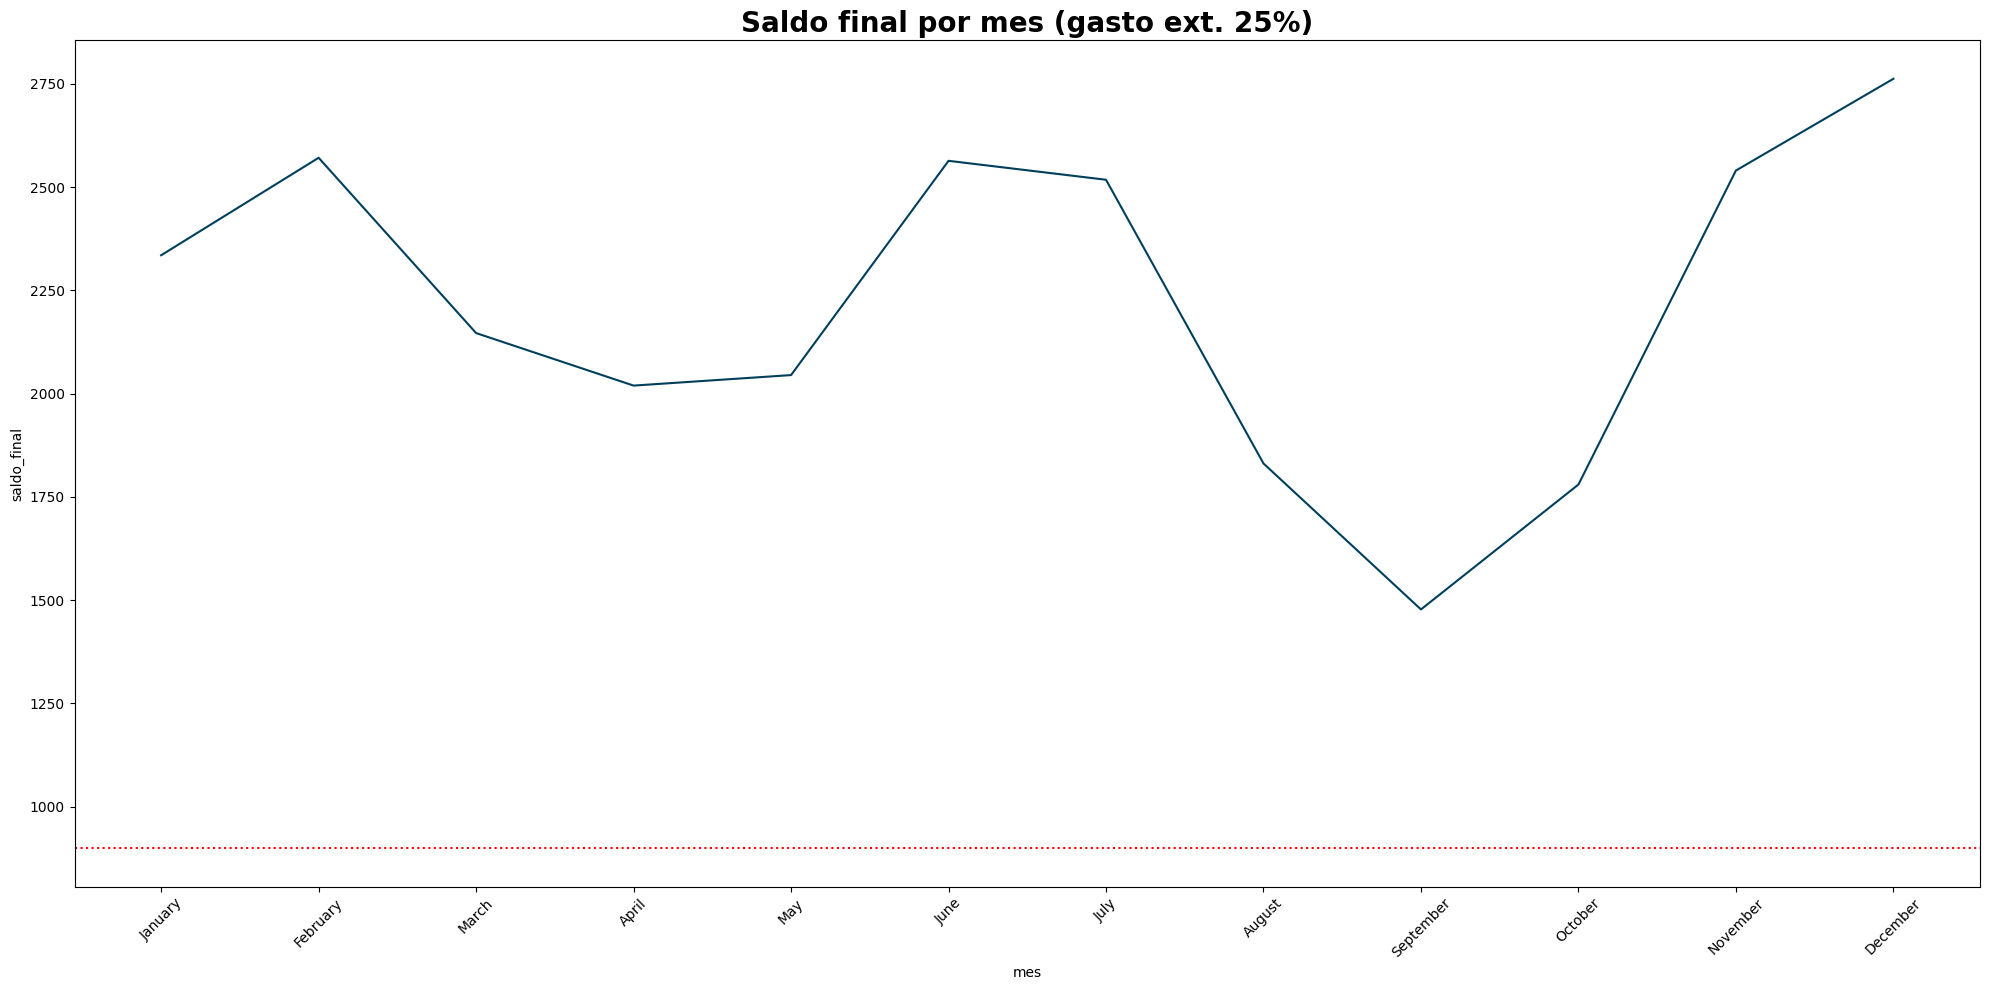


=== Escenario con el 50% de gasto extraordinario ===


C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\3821141133.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mes_gas_ext = df_opt.groupby("mes").agg(


,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-3339.75,1886.65
February,2859.07,-2623.09,2122.63
March,2446.67,-2871.03,1698.27
April,2663.34,-3000.11,1361.50
May,3097.48,-3296.34,1162.64
June,2598.59,-2079.94,1681.29
July,3157.15,-3558.81,1279.63
August,2248.55,-2935.34,592.84
September,2318.62,-2801.23,110.23


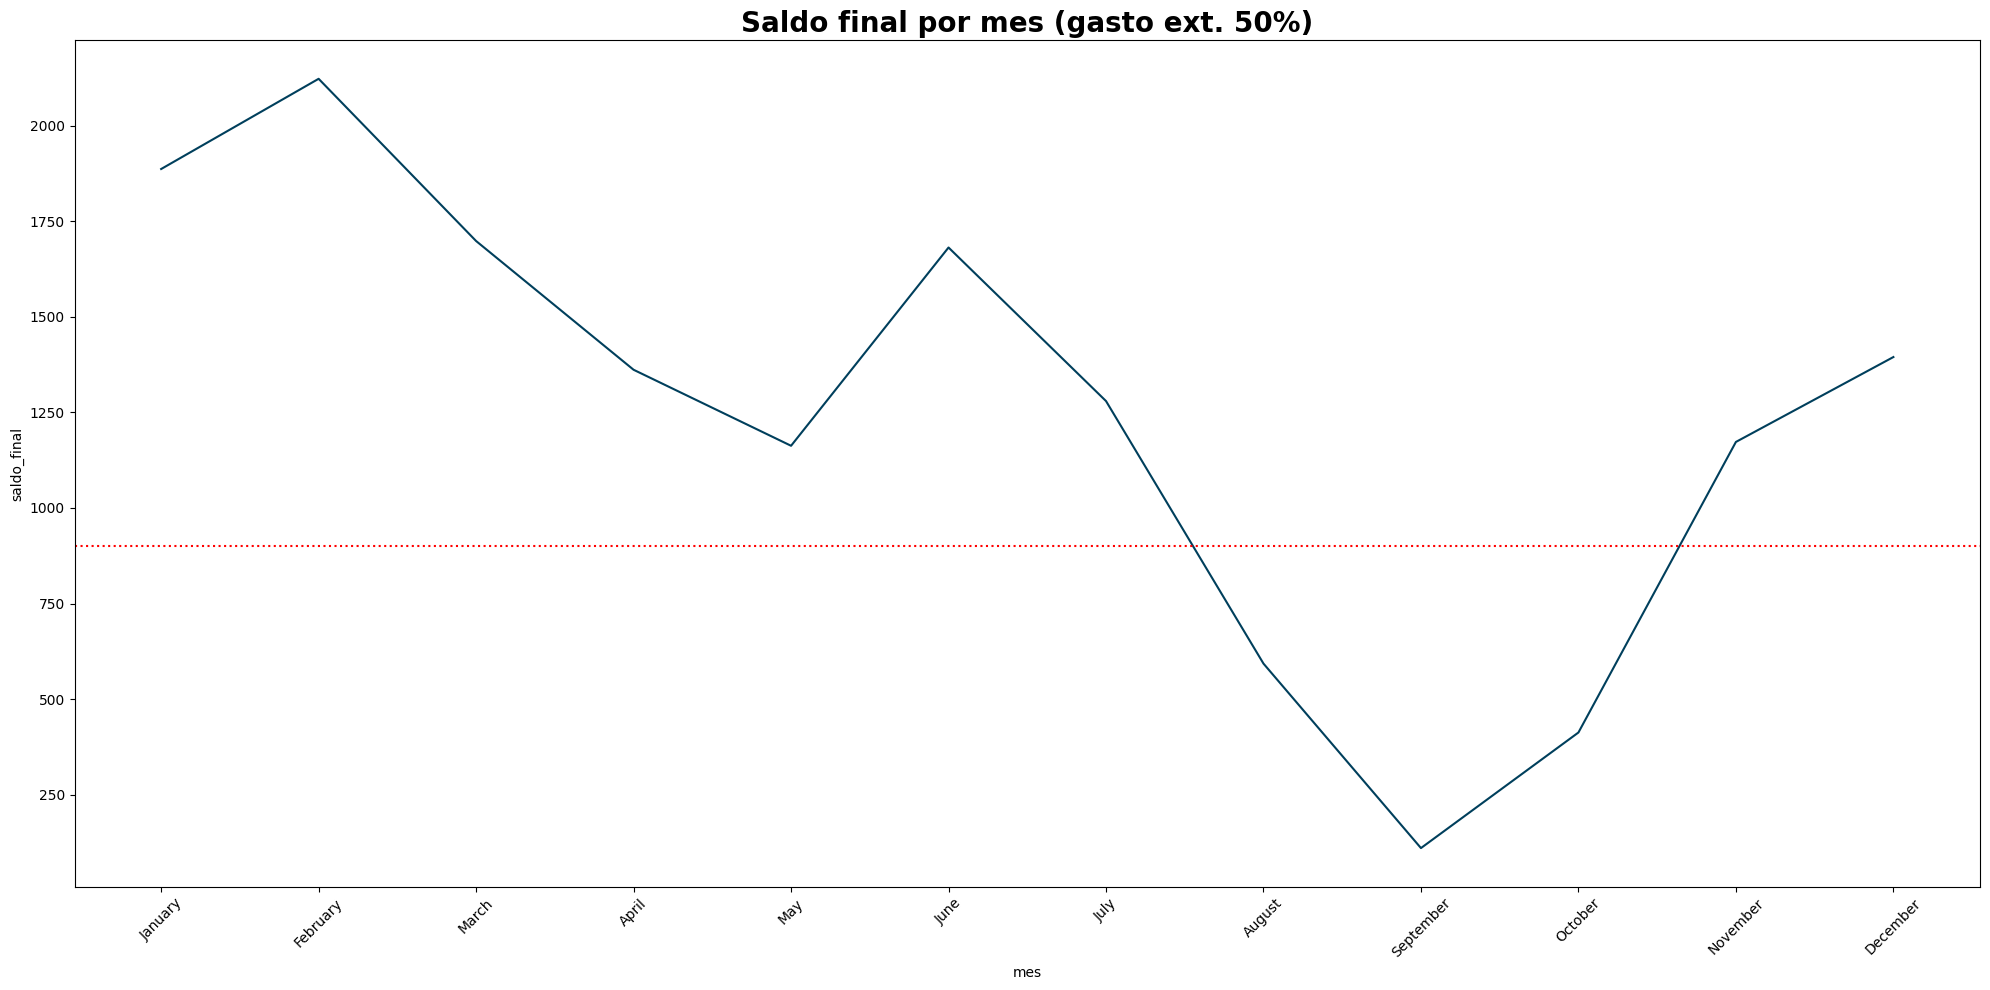


=== Escenario con el 75% de gasto extraordinario ===


C:\Users\maxim\AppData\Local\Temp\ipykernel_18564\3821141133.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mes_gas_ext = df_opt.groupby("mes").agg(


,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-3788.14,1438.26
February,2859.07,-2623.09,1674.24
March,2446.67,-2871.03,1249.88
April,2663.34,-3209.76,703.46
May,3097.48,-3520.63,280.31
June,2598.59,-2079.94,798.96
July,3157.15,-3914.66,41.45
August,2248.55,-2935.34,-645.34
September,2318.62,-2930.50,-1257.22


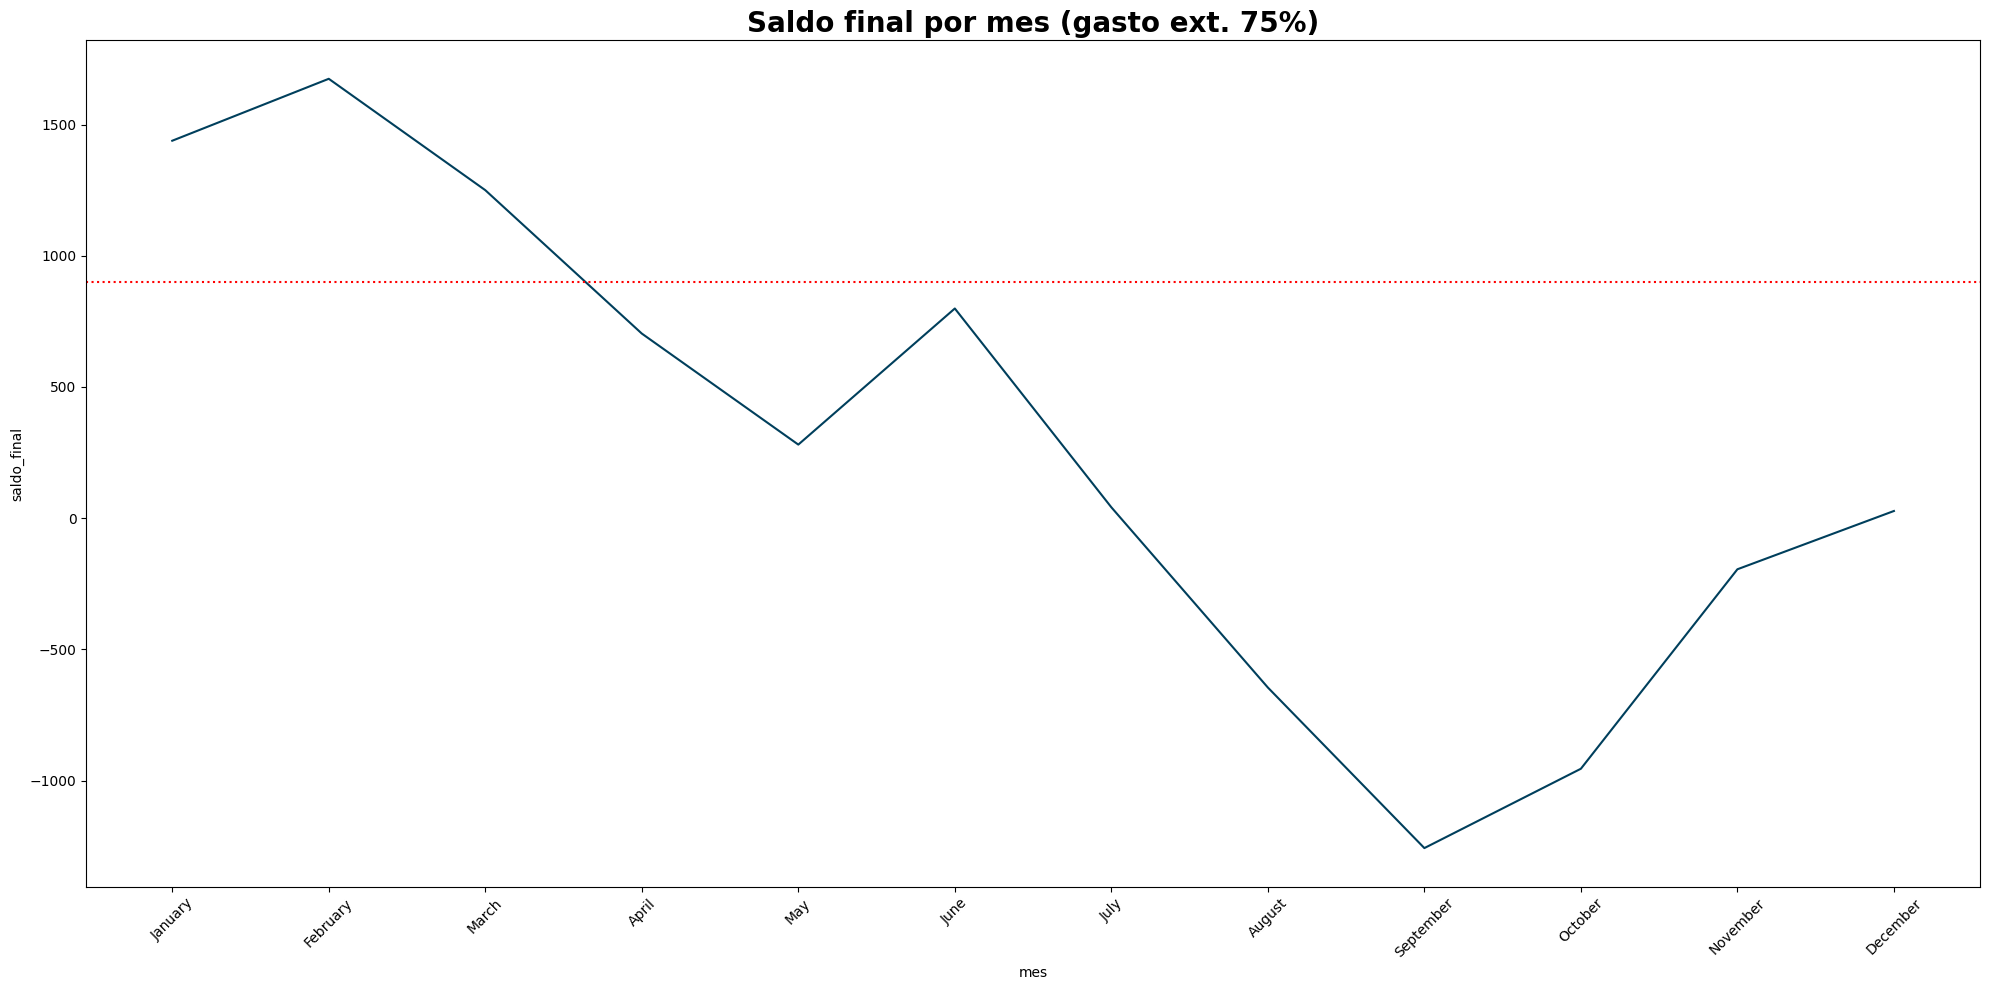

In [54]:
df_mes_gas_ext_por = {}

for por,df_opt in dfs_optimizados.items():
    df_mes_gas_ext = df_opt.groupby("mes").agg(
        ingresos=("importe_eur", lambda x: x[x>0].sum()),
        gastos=("importe_eur", lambda x: x[x<0].sum()),
        saldo_final=("saldo_post_movimiento", "last")
    )
    
    df_mes_gas_ext_por[por] = df_mes_gas_ext

    print(f"\n=== Escenario con el {int(por*100)}% de gasto extraordinario ===")
    display(df_mes_gas_ext)
    plt.figure(figsize=(20, 10))
    sns.lineplot(data=df_mes_gas_ext, x="mes", y="saldo_final")
    plt.title(f"Saldo final por mes (gasto ext. {int(por*100)}%)")
    plt.axhline(y=saldo_seguridad, color="red", linestyle=":")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(outdir / f"saldo_final_{int(por*100)}_gasto_ext.png")
    plt.show()
    plt.close()
    



### Guardamos un CSV de un plano ideal al 50%

In [55]:
try:
    filename = "gastos_optimizados_50%"
    output_path = project_root / "data" / "raw" / filename
    csv_optimizado = dfs_optimizados[0.50].to_csv(output_path,index = False)
    print(f"El csv: {filename} fue generado con exito.")
except Exception as ex:
    print(ex)

El csv: gastos_optimizados_50% fue generado con exito.


Interpretacion breve:
- Con solo el 25% de los gastos extraordinarios, sigue siendo un plan ideal para el cliente ya que en todos los meses del año supera su saldo de seguridad. 
- Reducir los gastos extraordinarios al 50% mejora sustencialmente el saldo final de la mayoria de los meses (9/12). El gasto de Julio sigue siendo el mas importante ya que es el que hace bajar el saldo final (vacaciones?)
- Con el 75% de los gastos extraordinarios, no vemos diferencias sustanciales para que el cliente pueda llegar a su saldo de seguridad.
- El cliente podria optar entre reducir esos gastos extraordinarios entre un 50% y un 75% para que mejore su situacion financiera.

2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?

In [56]:
#genero una variable con el tipo

ingresos = df[df["tipo_movimiento_general"] == "ingreso de dinero"]["importe_eur"]

In [57]:
#contando los ingresos como salarios e ingresos puntuales que el cliente acepta como trabajos extras, sacamos la media de ingresos. (evitamos ingresos de poco dinero, como Bizum, ya que sino baja la media de ingresos.)
media_ingresos = round(ingresos.mean(),2)
f"La media de los ingresos ronda los {media_ingresos}"

'La media de los ingresos ronda los 955.59'

La media de los ingresos no representa fermentemente a lo que en verdad ingresa en su cuenta. Sin embargo, estan por encima del saldo de seguridad acordado con el cliente.

De enero a septiembre vemos que hay meses que presenta gastos extraordinarios, los cuales modifican sustenciamente el saldo a fin de mes. Podemos comprobar que a partir de que el cliente no tiene más esos gastos, el saldo final sube levemente. Hay que tener en cuenta que los gastos arastraron una baja sustancial mes a mes por lo que es ese el motivo del crecimiento de forma leve. 

3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

de Enero a Septiembre son los meses que perjudicaron el saldo del cliente. Los picos son ENERO Y JULIO.

### Pregunta de negocio

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

Podemos afirmar que el cliente tuvo una caida notoria de su saldo debido a gastos extraordinarios que afectaron el ahorro mensual. Eran gastos que se generaban en un momento donde el cliente no disponia de ese dinero, por lo que por eso llega a negativo, presentando una preocupante situacion. 
La manera de optimizar la estructura de gastos seria, no gastar mas de lo que tengo.
Por lo que proponemos unas Acciones concretas a relizar:

- (1)Controlar principalmente los gastos extraordinarios. Si no dispongo de ese dinero, intentar no gastarlo.
- (2)En caso de necesitar hacer esos gastos extraordinarios, reducirlos entre un 50% y 75%. Recomendamos el 50% para que no baje sustancialmente la calidad de vida.
- (3)Reducir un 15% de Alimentación. Hay dias como los martes y los sabados que se consume entre un 15% y un 18% mas en Alimentación.
- (4)Terminar de pagar prestamos personal, estos prestamos personales existen por los gastos extraordinarios. Sin embargo, al reducir un porcentaje de los gastso extraordinarios, podria reducir el préstamo personal.


### TABLA COMPARATIVA: ESCENARIO ACTUAL VS OPTIMIZADO

In [58]:
from src.report_html import generar_html

generar_html(df_mes_ingreso_y_gasto,df_mes_gas_ext_por,saldo_seguridad)


✅ Reporte guardado con éxito en: C:\Users\maxim\Proyectos\analisis_gastos_personales\reports\tabla_comparativa.html


### Reporte final.

In [59]:
from src.reporte_final import generar_reporte_final

generar_reporte_final(saldo_seguridad=900, fecha_reporte=datetime.now(),cliente="Maximiliano Cóceres")

✅ Reporte generado: c:\Users\maxim\Proyectos\analisis_gastos_personales\notebooks\..\reports\reporte_personalizado.html
📊 Tamaño: 1.01 MB


WindowsPath('../reports/reporte_personalizado.html')